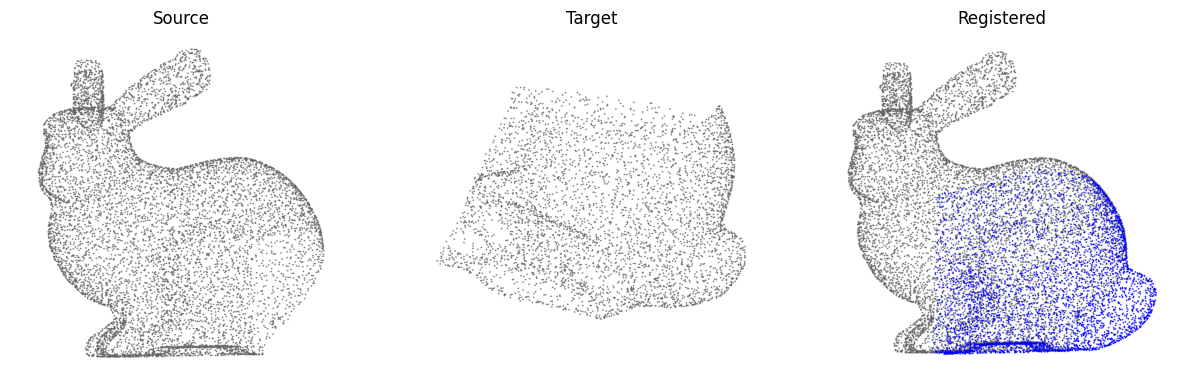

In [ ]:
from ezonnx import RAP, visualize_point_clouds
model = RAP()
clouds = ["samples/bunny_source.ply","samples/bunny_target.ply"]
res = model(clouds)
visualize_point_clouds(["Source", "Target","Registered"], 
                       [clouds[0], clouds[1], [res.data[0], res.data[1]]])

voxel_size=0.00600, des_r=0.12005, sampled keypoints=[656, 324]
[[ 0.94959534  0.29603967 -0.10309802 -0.36924257]
 [-0.31214138  0.86260223 -0.39810193  0.33010754]
 [-0.02892139  0.4102169   0.91152929 -0.32448423]
 [ 0.          0.          0.          1.        ]]


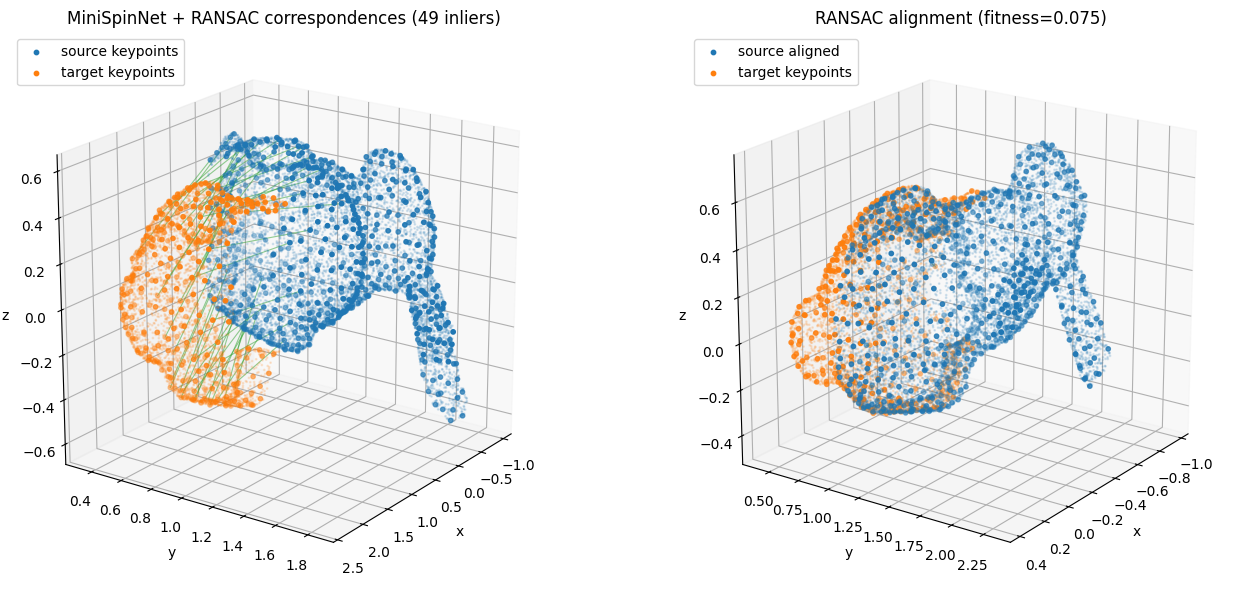

In [3]:
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d

from ezonnx.models.rap.rap import _calculate_voxel_coverage

if len(clouds) < 2:
    raise ValueError("At least two point clouds are required.")
if model._spinnet is None:
    raise RuntimeError("MiniSpinNet is not loaded. Confirm that mini_spinnet.onnx is available.")

point_clouds, _ = model._load_inputs(clouds[:2])
params = model._compute_effective_preprocess_params(point_clouds)

voxel_parts = []
fps_source_parts = []
target_per_part = []

for pts in point_clouds:
    voxel_pts = model._voxel_downsample(pts, params["voxel_size"])
    voxel_parts.append(voxel_pts)

    fps_pts = model._remove_statistical_outliers(voxel_pts)
    pre_fps_cap = 20 * model._max_points_per_part
    if len(fps_pts) > pre_fps_cap:
        sub_idx = model._rng.choice(len(fps_pts), pre_fps_cap, replace=False)
        fps_pts = fps_pts[sub_idx]
    fps_source_parts.append(fps_pts.astype(np.float32, copy=True))

    if model._adaptive_parameters:
        target_points = int(
            _calculate_voxel_coverage(fps_pts, params["allocated_voxel_size"]) * params["voxel_ratio"]
        )
        target_points = max(model._min_points_per_part, target_points)
        target_points = min(target_points, len(fps_pts), model._max_points_per_part)
    else:
        target_points = min(model._num_points, len(fps_pts))

    if target_points <= 0:
        raise ValueError("Preprocessing produced zero sampled keypoints.")
    target_per_part.append(int(target_points))

fps_indices = model._batched_fps_indices(fps_source_parts, target_per_part)
keypoint_parts = [
    fps_pts[idx].astype(np.float32, copy=True)
    for fps_pts, idx in zip(fps_source_parts, fps_indices)
]
feature_parts = [
    model._spinnet(pts_ref, kpts, params["des_r"])
    for pts_ref, kpts in zip(voxel_parts, keypoint_parts)
]

def to_o3d_pcd(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(np.asarray(points, dtype=np.float64))
    return pcd

def to_o3d_feature(features):
    feat = o3d.pipelines.registration.Feature()
    feat.data = np.asarray(features, dtype=np.float64).T
    return feat

ransac_distance = max(params["voxel_size"] * 4.0, 1e-3)
ransac_result = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    to_o3d_pcd(keypoint_parts[0]),
    to_o3d_pcd(keypoint_parts[1]),
    to_o3d_feature(feature_parts[0]),
    to_o3d_feature(feature_parts[1]),
    mutual_filter=True,
    max_correspondence_distance=float(ransac_distance),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
    ransac_n=3,
    checkers=[
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(float(ransac_distance)),
    ],
    criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999),
)

correspondences = np.asarray(ransac_result.correspondence_set)
if correspondences.size == 0:
    raise RuntimeError("RANSAC did not find any inlier correspondences.")

transform = ransac_result.transformation
source_voxel_aligned = (voxel_parts[0] @ transform[:3, :3].T + transform[:3, 3]).astype(np.float32)
source_keypoints = keypoint_parts[0]
target_keypoints = keypoint_parts[1]
source_keypoints_aligned = (source_keypoints @ transform[:3, :3].T + transform[:3, 3]).astype(np.float32)

display_corr = correspondences
max_lines = 80
if len(display_corr) > max_lines:
    display_corr = display_corr[np.linspace(0, len(display_corr) - 1, max_lines, dtype=int)]

stacked = np.concatenate([voxel_parts[0], voxel_parts[1]], axis=0)
shift = np.array([max(np.ptp(stacked[:, 0]), 1e-3) * 1.4, 0.0, 0.0], dtype=np.float32)
target_voxel_shifted = voxel_parts[1] + shift
target_keypoints_shifted = target_keypoints + shift

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(voxel_parts[0][:, 0], voxel_parts[0][:, 1], voxel_parts[0][:, 2], s=1, alpha=0.15, color="tab:blue")
ax1.scatter(target_voxel_shifted[:, 0], target_voxel_shifted[:, 1], target_voxel_shifted[:, 2], s=1, alpha=0.15, color="tab:orange")
ax1.scatter(source_keypoints[:, 0], source_keypoints[:, 1], source_keypoints[:, 2], s=10, color="tab:blue", label="source keypoints")
ax1.scatter(target_keypoints_shifted[:, 0], target_keypoints_shifted[:, 1], target_keypoints_shifted[:, 2], s=10, color="tab:orange", label="target keypoints")
for src_idx, tgt_idx in display_corr:
    src = source_keypoints[src_idx]
    tgt = target_keypoints_shifted[tgt_idx]
    ax1.plot([src[0], tgt[0]], [src[1], tgt[1]], [src[2], tgt[2]], color="tab:green", alpha=0.5, linewidth=0.8)
ax1.set_title(f"MiniSpinNet + RANSAC correspondences ({len(correspondences)} inliers)")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(source_voxel_aligned[:, 0], source_voxel_aligned[:, 1], source_voxel_aligned[:, 2], s=1, alpha=0.15, color="tab:blue")
ax2.scatter(voxel_parts[1][:, 0], voxel_parts[1][:, 1], voxel_parts[1][:, 2], s=1, alpha=0.15, color="tab:orange")
ax2.scatter(source_keypoints_aligned[:, 0], source_keypoints_aligned[:, 1], source_keypoints_aligned[:, 2], s=10, color="tab:blue", label="source aligned")
ax2.scatter(target_keypoints[:, 0], target_keypoints[:, 1], target_keypoints[:, 2], s=10, color="tab:orange", label="target keypoints")
for src_idx, tgt_idx in display_corr:
    src = source_keypoints_aligned[src_idx]
    tgt = target_keypoints[tgt_idx]
    ax2.plot([src[0], tgt[0]], [src[1], tgt[1]], [src[2], tgt[2]], color="tab:green", alpha=0.5, linewidth=0.8)
ax2.set_title(f"RANSAC alignment (fitness={ransac_result.fitness:.3f})")

for ax in (ax1, ax2):
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=20, azim=35)
    ax.legend(loc="upper left")

plt.tight_layout()
print(f"voxel_size={params['voxel_size']:.5f}, des_r={params['des_r']:.5f}, sampled keypoints={[len(x) for x in keypoint_parts]}")
print(transform)
plt.show()


voxel_size=0.00600, normal_radius=0.01201, feature_radius=0.12005, sampled keypoints=[656, 324]
[[ 0.33406222 -0.51675524 -0.78826801  0.39502198]
 [ 0.86928463  0.49219142  0.04573655  0.6160155 ]
 [ 0.36434414 -0.70050812  0.61362995  0.62700082]
 [ 0.          0.          0.          1.        ]]


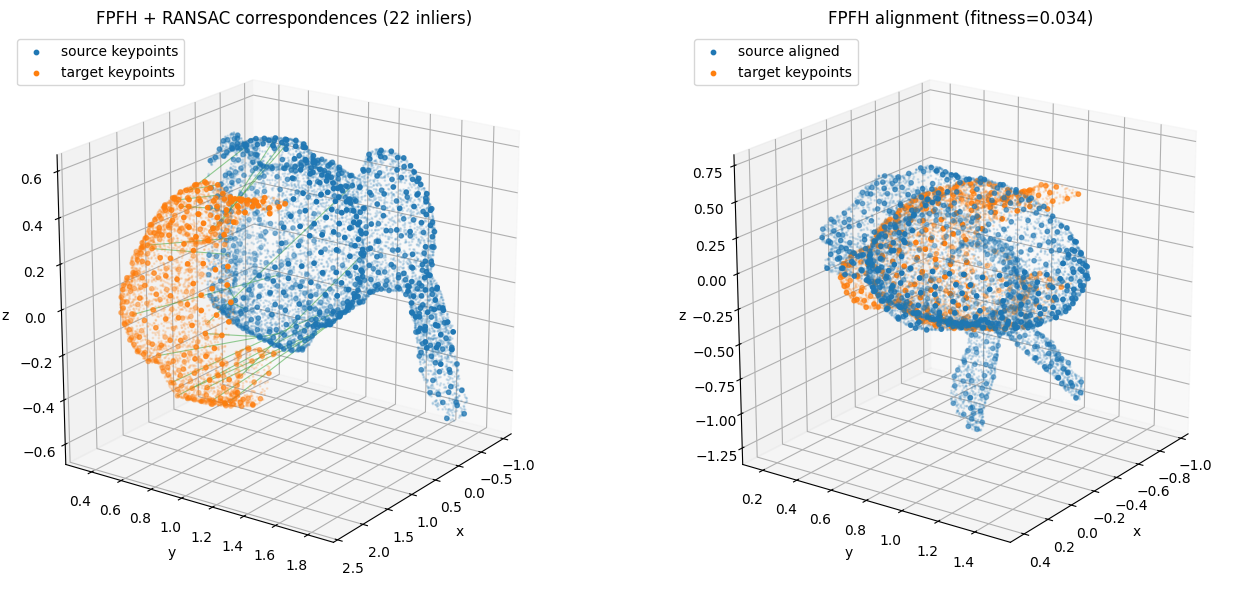

: 

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import open3d as o3d

from ezonnx.models.rap.rap import _calculate_voxel_coverage

if len(clouds) < 2:
    raise ValueError("At least two point clouds are required.")

point_clouds_fpfh, _ = model._load_inputs(clouds[:2])
params_fpfh = model._compute_effective_preprocess_params(point_clouds_fpfh)

voxel_parts_fpfh = []
fps_source_parts_fpfh = []
target_per_part_fpfh = []

for pts in point_clouds_fpfh:
    voxel_pts = model._voxel_downsample(pts, params_fpfh["voxel_size"])
    voxel_parts_fpfh.append(voxel_pts)

    fps_pts = model._remove_statistical_outliers(voxel_pts)
    pre_fps_cap = 20 * model._max_points_per_part
    if len(fps_pts) > pre_fps_cap:
        sub_idx = model._rng.choice(len(fps_pts), pre_fps_cap, replace=False)
        fps_pts = fps_pts[sub_idx]
    fps_source_parts_fpfh.append(fps_pts.astype(np.float32, copy=True))

    if model._adaptive_parameters:
        target_points = int(
            _calculate_voxel_coverage(fps_pts, params_fpfh["allocated_voxel_size"]) * params_fpfh["voxel_ratio"]
        )
        target_points = max(model._min_points_per_part, target_points)
        target_points = min(target_points, len(fps_pts), model._max_points_per_part)
    else:
        target_points = min(model._num_points, len(fps_pts))

    if target_points <= 0:
        raise ValueError("Preprocessing produced zero sampled keypoints.")
    target_per_part_fpfh.append(int(target_points))

fps_indices_fpfh = model._batched_fps_indices(fps_source_parts_fpfh, target_per_part_fpfh)
keypoint_parts_fpfh = [
    fps_pts[idx].astype(np.float32, copy=True)
    for fps_pts, idx in zip(fps_source_parts_fpfh, fps_indices_fpfh)
]

def to_o3d_pcd_fpfh(points):
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(np.asarray(points, dtype=np.float64))
    return pcd

def compute_fpfh(points, normal_radius, feature_radius):
    pcd = to_o3d_pcd_fpfh(points)
    pcd.estimate_normals(
        o3d.geometry.KDTreeSearchParamHybrid(radius=float(normal_radius), max_nn=30)
    )
    feat = o3d.pipelines.registration.compute_fpfh_feature(
        pcd,
        o3d.geometry.KDTreeSearchParamHybrid(radius=float(feature_radius), max_nn=100),
    )
    return pcd, feat

normal_radius_fpfh = max(params_fpfh["voxel_size"] * 2.0, 1e-3)
feature_radius_fpfh = max(params_fpfh["des_r"], params_fpfh["voxel_size"] * 5.0)

source_pcd_fpfh, source_feat_fpfh = compute_fpfh(
    keypoint_parts_fpfh[0], normal_radius_fpfh, feature_radius_fpfh
)
target_pcd_fpfh, target_feat_fpfh = compute_fpfh(
    keypoint_parts_fpfh[1], normal_radius_fpfh, feature_radius_fpfh
)

ransac_distance_fpfh = max(params_fpfh["voxel_size"] * 4.0, 1e-3)
ransac_result_fpfh = o3d.pipelines.registration.registration_ransac_based_on_feature_matching(
    source_pcd_fpfh,
    target_pcd_fpfh,
    source_feat_fpfh,
    target_feat_fpfh,
    mutual_filter=True,
    max_correspondence_distance=float(ransac_distance_fpfh),
    estimation_method=o3d.pipelines.registration.TransformationEstimationPointToPoint(False),
    ransac_n=3,
    checkers=[
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnEdgeLength(0.9),
        o3d.pipelines.registration.CorrespondenceCheckerBasedOnDistance(float(ransac_distance_fpfh)),
    ],
    criteria=o3d.pipelines.registration.RANSACConvergenceCriteria(100000, 0.999),
)

correspondences_fpfh = np.asarray(ransac_result_fpfh.correspondence_set)
if correspondences_fpfh.size == 0:
    raise RuntimeError("RANSAC did not find any inlier correspondences for FPFH.")

transform_fpfh = ransac_result_fpfh.transformation
source_voxel_aligned_fpfh = (
    voxel_parts_fpfh[0] @ transform_fpfh[:3, :3].T + transform_fpfh[:3, 3]
).astype(np.float32)
source_keypoints_fpfh = keypoint_parts_fpfh[0]
target_keypoints_fpfh = keypoint_parts_fpfh[1]
source_keypoints_aligned_fpfh = (
    source_keypoints_fpfh @ transform_fpfh[:3, :3].T + transform_fpfh[:3, 3]
).astype(np.float32)

display_corr_fpfh = correspondences_fpfh
max_lines_fpfh = 80
if len(display_corr_fpfh) > max_lines_fpfh:
    display_corr_fpfh = display_corr_fpfh[
        np.linspace(0, len(display_corr_fpfh) - 1, max_lines_fpfh, dtype=int)
    ]

stacked_fpfh = np.concatenate([voxel_parts_fpfh[0], voxel_parts_fpfh[1]], axis=0)
shift_fpfh = np.array([max(np.ptp(stacked_fpfh[:, 0]), 1e-3) * 1.4, 0.0, 0.0], dtype=np.float32)
target_voxel_shifted_fpfh = voxel_parts_fpfh[1] + shift_fpfh
target_keypoints_shifted_fpfh = target_keypoints_fpfh + shift_fpfh

fig = plt.figure(figsize=(14, 6))
ax1 = fig.add_subplot(1, 2, 1, projection="3d")
ax1.scatter(voxel_parts_fpfh[0][:, 0], voxel_parts_fpfh[0][:, 1], voxel_parts_fpfh[0][:, 2], s=1, alpha=0.15, color="tab:blue")
ax1.scatter(target_voxel_shifted_fpfh[:, 0], target_voxel_shifted_fpfh[:, 1], target_voxel_shifted_fpfh[:, 2], s=1, alpha=0.15, color="tab:orange")
ax1.scatter(source_keypoints_fpfh[:, 0], source_keypoints_fpfh[:, 1], source_keypoints_fpfh[:, 2], s=10, color="tab:blue", label="source keypoints")
ax1.scatter(target_keypoints_shifted_fpfh[:, 0], target_keypoints_shifted_fpfh[:, 1], target_keypoints_shifted_fpfh[:, 2], s=10, color="tab:orange", label="target keypoints")
for src_idx, tgt_idx in display_corr_fpfh:
    src = source_keypoints_fpfh[src_idx]
    tgt = target_keypoints_shifted_fpfh[tgt_idx]
    ax1.plot([src[0], tgt[0]], [src[1], tgt[1]], [src[2], tgt[2]], color="tab:green", alpha=0.5, linewidth=0.8)
ax1.set_title(f"FPFH + RANSAC correspondences ({len(correspondences_fpfh)} inliers)")

ax2 = fig.add_subplot(1, 2, 2, projection="3d")
ax2.scatter(source_voxel_aligned_fpfh[:, 0], source_voxel_aligned_fpfh[:, 1], source_voxel_aligned_fpfh[:, 2], s=1, alpha=0.15, color="tab:blue")
ax2.scatter(voxel_parts_fpfh[1][:, 0], voxel_parts_fpfh[1][:, 1], voxel_parts_fpfh[1][:, 2], s=1, alpha=0.15, color="tab:orange")
ax2.scatter(source_keypoints_aligned_fpfh[:, 0], source_keypoints_aligned_fpfh[:, 1], source_keypoints_aligned_fpfh[:, 2], s=10, color="tab:blue", label="source aligned")
ax2.scatter(target_keypoints_fpfh[:, 0], target_keypoints_fpfh[:, 1], target_keypoints_fpfh[:, 2], s=10, color="tab:orange", label="target keypoints")
for src_idx, tgt_idx in display_corr_fpfh:
    src = source_keypoints_aligned_fpfh[src_idx]
    tgt = target_keypoints_fpfh[tgt_idx]
    ax2.plot([src[0], tgt[0]], [src[1], tgt[1]], [src[2], tgt[2]], color="tab:green", alpha=0.5, linewidth=0.8)
ax2.set_title(f"FPFH alignment (fitness={ransac_result_fpfh.fitness:.3f})")

for ax in (ax1, ax2):
    ax.set_box_aspect((1, 1, 1))
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    ax.view_init(elev=20, azim=35)
    ax.legend(loc="upper left")

plt.tight_layout()
print(
    f"voxel_size={params_fpfh['voxel_size']:.5f}, normal_radius={normal_radius_fpfh:.5f}, "
    f"feature_radius={feature_radius_fpfh:.5f}, sampled keypoints={[len(x) for x in keypoint_parts_fpfh]}"
)
print(transform_fpfh)
plt.show()
